# Ensemble Convnext and Swin T

## Setup

In [1]:
# Import Library
import os
import warnings

import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms
from torchvision.models import convnext_base, ConvNeXt_Base_Weights
from torchvision.models import swin_t, Swin_T_Weights
import torchvision.models as models

warnings.filterwarnings("ignore")

In [2]:
# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
NUM_WORKERS = 0

CSV_PATH = "dataset_filtered.csv"

TEST_DIR = "test"

CONVNEXT_WEIGHT = "convnext.pth"
SWIN_WEIGHT = "swin_t.pth"

IMAGE_SIZE = 224

SEED = 42

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
# Load Dataset
df = pd.read_csv(CSV_PATH)

print(f"Total data : {len(df)}")
print(f"Jumlah kelas : {df['label'].nunique()}")

display(df.head())

Total data : 26197
Jumlah kelas : 3


,id,label,label_number,label_folder_name,file_name,file_path,not_corrupt,final_path,use_no_bg,file_path_no_bg,bg_removed_success,fg_percentage,final_path_resized
0,R_1,Recyclable,0,0_Recyclable,R_1.jpg,train/0_Recyclable/R_1.jpg,True,train/0_Recyclable/R_1.jpg,False,dataset_no_bg\0_Recyclable\R_1.jpg,True,58.345939,dataset_final\Recyclable\R_1.jpg
1,R_2,Recyclable,0,0_Recyclable,R_2.jpg,train/0_Recyclable/R_2.jpg,True,train/0_Recyclable/R_2.jpg,False,dataset_no_bg\0_Recyclable\R_2.jpg,True,19.604570,dataset_final\Recyclable\R_2.jpg
2,R_3,Recyclable,0,0_Recyclable,R_3.jpg,train/0_Recyclable/R_3.jpg,True,train/0_Recyclable/R_3.jpg,False,dataset_no_bg\0_Recyclable\R_3.jpg,True,20.310074,dataset_final\Recyclable\R_3.jpg
3,R_4,Recyclable,0,0_Recyclable,R_4.jpg,train/0_Recyclable/R_4.jpg,True,train/0_Recyclable/R_4.jpg,False,dataset_no_bg\0_Recyclable\R_4.jpg,True,20.146382,dataset_final\Recyclable\R_4.jpg
4,R_5,Recyclable,0,0_Recyclable,R_5.jpg,train/0_Recyclable/R_5.jpg,True,train/0_Recyclable/R_5.jpg,False,dataset_no_bg\0_Recyclable\R_5.jpg,True,28.145057,dataset_final\Recyclable\R_5.jpg


In [4]:
# Label Mapping
label_to_idx = {
    label: idx
    for idx, label in enumerate(sorted(df["label"].unique()))
}

idx_to_label = {v: k for k, v in label_to_idx.items()}

class_names = sorted(df["label"].unique())

print("Jumlah kelas :", len(class_names))
print(label_to_idx)

Jumlah kelas : 3
{'Electronic': 0, 'Organic': 1, 'Recyclable': 2}


In [5]:
# eval
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
class EvalDataset(Dataset):
    """
    Dataset untuk validasi (nanti di split)
    """
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['file_path']).convert('RGB')
        img = self.transform(img)
        return img, label_to_idx[row['label']]

In [7]:
class MixedDataset(Dataset):
    """
    Dataset bakal memilih acak gambar yang di-augmentasi berikut:
    - Gambar asli + augmentasi (sedikit lebih agresif)
    - Gambar no-background + augmentasi (jika use_no_bg=True)
    """
    def __init__(self, dataframe, heavy_transform, light_transform):
        self.df = dataframe.reset_index(drop=True)
        self.heavy = heavy_transform
        self.light = light_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = label_to_idx[row['label']]

        if row['use_no_bg'] and random.random() < 0.5:
            img = Image.open(row['final_path']).convert('RGB')
            img = self.light(img)
        else:
            img = Image.open(row['file_path']).convert('RGB')
            img = self.heavy(img)
        return img, label

In [8]:
# buat heavy augment
htrain = transforms.Compose([
    transforms.Resize((256)),
    transforms.RandomResizedCrop(224, scale=(0.08,1.0), ratio=(0.75,1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# light augment
ltrain = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.3,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# eval
etransform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
# Validation Split
full_dataset = MixedDataset(df, htrain, ltrain)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

val_df = df.iloc[val_dataset.indices].reset_index(drop=True)

val_dataset = EvalDataset(
    val_df,
    eval_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Validation samples: {len(val_dataset)}")

Validation samples: 5240


## Load Model

In [10]:
# Model Factory
def build_model(model_name='convnext_tiny', num_classes=3):
    """
    Factory model untuk sekali inisiasi.
    """

    match model_name:

        case 'convnext_tiny':
            model = models.convnext_tiny(
                weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
            )
            model.classifier[2] = nn.Linear(
                model.classifier[2].in_features,
                num_classes
            )

        case 'swin_t':
            model = models.swin_t(
                weights=models.Swin_T_Weights.IMAGENET1K_V1
            )
            model.head = nn.Linear(
                model.head.in_features,
                num_classes
            )

        case _:
            raise ValueError(f"Model '{model_name}' tidak didukung.")

    return model

In [11]:
# Load Trained Model
def load_model(model_name, weight_path, num_classes):
    """
    Build model, load trained weights, move to device,
    and set to evaluation mode.
    """

    net = build_model(model_name=model_name, num_classes=num_classes)

    state_dict = torch.load(weight_path, map_location=DEVICE)
    net.load_state_dict(state_dict)

    net.to(DEVICE)
    net.eval()

    return net

In [12]:
# Initialize Models
convnext_model = load_model(
    model_name="convnext_tiny",
    weight_path=CONVNEXT_WEIGHT,
    num_classes=len(class_names)
)
print("ConvNeXt Tiny loaded")

swin_model = load_model(
    model_name="swin_t",
    weight_path=SWIN_WEIGHT,
    num_classes=len(class_names)
)

print("Swin-T loaded")

ConvNeXt Tiny loaded
Swin-T loaded


## Ensemble Predictor

In [13]:
# Ensemble Predictor
class EnsemblePredictor:
    def __init__(self, models):
        self.models = models

    @torch.no_grad()
    def predict(self, images):
        """
        Soft Voting Prediction
        """
        probs = []

        for model in self.models:
            outputs = model(images)
            probs.append(torch.softmax(outputs, dim=1))

        avg_prob = torch.mean(torch.stack(probs), dim=0)

        predictions = avg_prob.argmax(dim=1)

        return predictions, avg_prob

# Initialize Ensemble
ensemble = EnsemblePredictor([
    convnext_model,
    swin_model
])

In [14]:
# Validation Prediction

y_true = []
y_pred = []

for images, labels in tqdm(val_loader, desc="Validation"):

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    preds, _ = ensemble.predict(images)

    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Validation samples : {len(y_true)}")

Validation: 100%|██████████| 164/164 [01:05<00:00,  2.50it/s]

Validation samples : 5240


## Evaluation

In [15]:
# Evaluation Metrics
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {f1:.4f}")

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Accuracy : 0.9882
Macro F1 : 0.9902

Classification Report
              precision    recall  f1-score   support

  Electronic       1.00      1.00      1.00       742
     Organic       1.00      0.98      0.99      2515
  Recyclable       0.97      0.99      0.98      1983

    accuracy                           0.99      5240
   macro avg       0.99      0.99      0.99      5240
weighted avg       0.99      0.99      0.99      5240



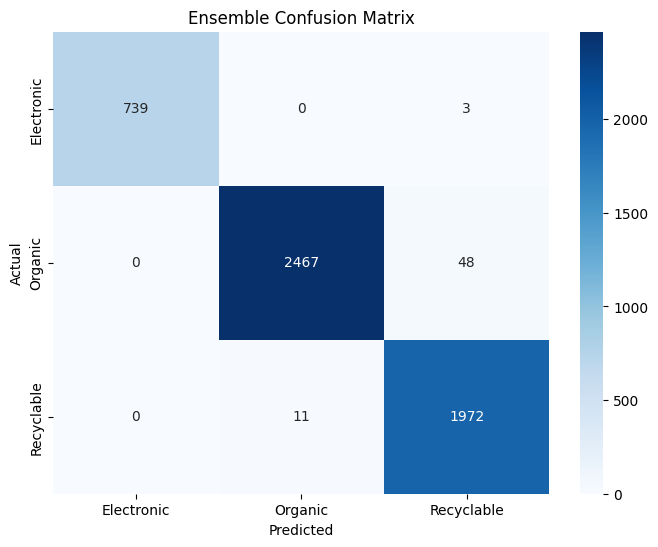

In [16]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Ensemble Confusion Matrix")

plt.show()

In [17]:
# Test Dataset
class TestDataset(Dataset):
    def __init__(self, ids, img_dir, transform):
        self.ids = ids
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        img = Image.open(
            os.path.join(self.img_dir, img_id)
        ).convert("RGB")

        img = self.transform(img)

        return img, img_id

In [18]:
# Test DataLoader
submission = pd.read_csv("submission.csv")

test_ids = submission["id"].astype(str) + ".jpg"

test_dataset = TestDataset(
    test_ids,
    TEST_DIR,
    eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Test samples : {len(test_dataset)}")

Test samples : 1458


In [19]:
# Test Prediction

image_ids = []
predictions = []

for images, ids in tqdm(test_loader, desc="Predict Test"):

    images = images.to(DEVICE)

    preds, _ = ensemble.predict(images)

    image_ids.extend(ids)
    predictions.extend(preds.cpu().numpy())

Predict Test: 100%|██████████| 46/46 [00:19<00:00,  2.32it/s]


In [21]:
# Create Submission
submission["predicted"] = [
    idx_to_label[p] for p in predictions
]

submission.to_csv(
    "submission_ensemble.csv",
    index=False
)

submission.head()

,id,predicted
0,1,Organic
1,2,Organic
2,3,Organic
3,4,Electronic
4,5,Recyclable
